# **1. Setup & Data Loading**




In [13]:
!pip install pm4py
import pm4py
log = pm4py.read_xes('/content/BPI Challenge 2017.xes.gz')


parsing log, completed traces ::   0%|          | 0/31509 [00:00<?, ?it/s]

        Action org:resource            concept:name  EventOrigin  \
0      Created       User_1    A_Create Application  Application   
1  statechange       User_1             A_Submitted  Application   
2      Created       User_1          W_Handle leads     Workflow   
3      Deleted       User_1          W_Handle leads     Workflow   
4      Created       User_1  W_Complete application     Workflow   

                 EventID lifecycle:transition  \
0  Application_652823628             complete   
1   ApplState_1582051990             complete   
2    Workitem_1298499574             schedule   
3    Workitem_1673366067             withdraw   
4    Workitem_1493664571             schedule   

                    time:timestamp           case:LoanGoal  \
0 2016-01-01 09:51:15.304000+00:00  Existing loan takeover   
1 2016-01-01 09:51:15.352000+00:00  Existing loan takeover   
2 2016-01-01 09:51:15.774000+00:00  Existing loan takeover   
3 2016-01-01 09:52:36.392000+00:00  Existing loa

# **2. Data Exploration**

In [19]:

print(log.head())
print(f"Rows: {len(log)}")

cases = log['case:concept:name'].nunique()
activities = log['concept:name'].nunique()

print(f"Case Number: {cases}")
print(f"Activity Type: {activities}")
print("\nTotal Activity Name:")
print(log['concept:name'].unique())

        Action org:resource            concept:name  EventOrigin  \
0      Created       User_1    A_Create Application  Application   
1  statechange       User_1             A_Submitted  Application   
2      Created       User_1          W_Handle leads     Workflow   
3      Deleted       User_1          W_Handle leads     Workflow   
4      Created       User_1  W_Complete application     Workflow   

                 EventID lifecycle:transition  \
0  Application_652823628             complete   
1   ApplState_1582051990             complete   
2    Workitem_1298499574             schedule   
3    Workitem_1673366067             withdraw   
4    Workitem_1493664571             schedule   

                    time:timestamp           case:LoanGoal  \
0 2016-01-01 09:51:15.304000+00:00  Existing loan takeover   
1 2016-01-01 09:51:15.352000+00:00  Existing loan takeover   
2 2016-01-01 09:51:15.774000+00:00  Existing loan takeover   
3 2016-01-01 09:52:36.392000+00:00  Existing loa

# **3. Process Discovery**

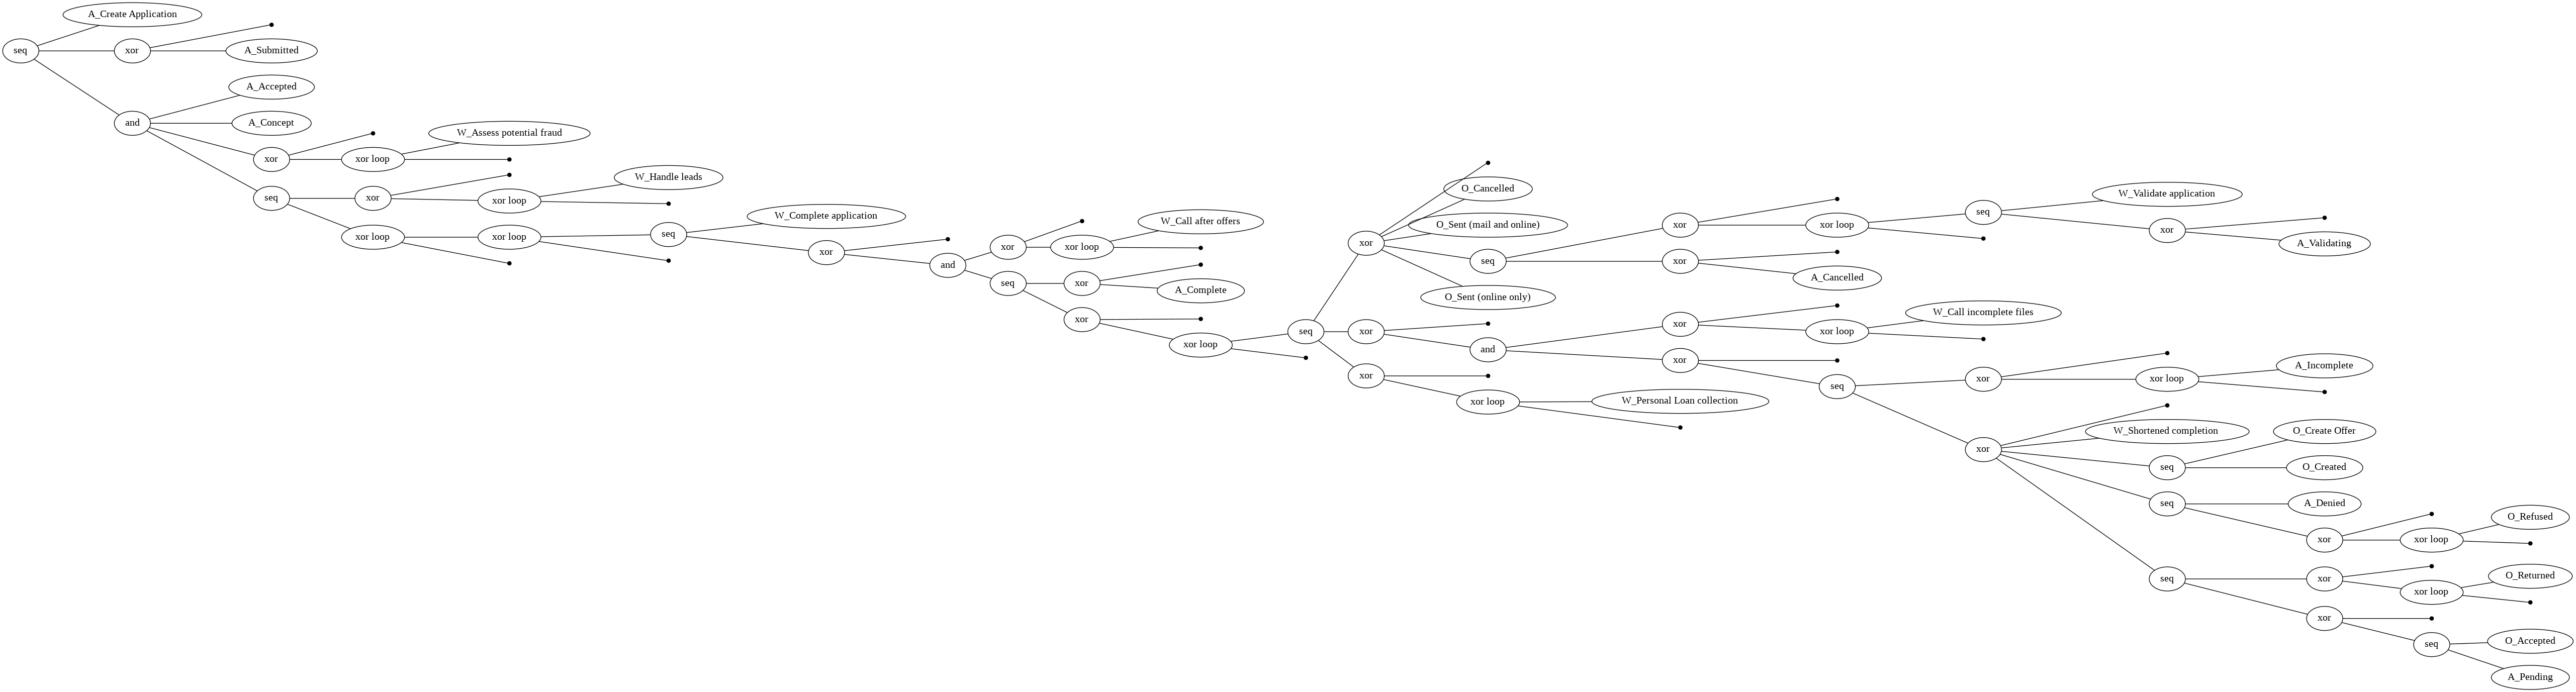

In [16]:

from pm4py.algo.discovery.inductive import algorithm as inductive_miner

process_tree = inductive_miner.apply(log)
pm4py.view_process_tree(process_tree)

In [20]:
from pm4py.algo.conformance.tokenreplay import algorithm as token_replay
from pm4py.objects.conversion.process_tree import converter as pt_converter

net, im, fm = pm4py.convert_to_petri_net(process_tree)

# run conformance checking
replayed = token_replay.apply(log, net, im, fm)

# calculate the fitness
fitness_values = [t['trace_fitness'] for t in replayed]
avg_fitness = sum(fitness_values) / len(fitness_values)
print(f"Avg. Fitness: {avg_fitness:.4f}")

replaying log with TBR, completed traces ::   0%|          | 0/15930 [00:00<?, ?it/s]

Avg. Fitness: 1.0000


# **4. Case Outcome Analysis**

In [22]:

active_rejection = log.groupby('case:concept:name')['concept:name'].apply(
    lambda x: x.isin(['A_Denied', 'O_Refused']).any()
).sum()

passive_cancellation = log.groupby('case:concept:name')['concept:name'].apply(
    lambda x: x.isin(['A_Cancelled', 'O_Cancelled']).any()
).sum()

total = len(log['case:concept:name'].unique())

print(f"Total Cases: {total}")
print(f"Active Rejection (From Bank): {active_rejection} ({active_rejection/total*100:.1f}%)")
print(f"Passive Cancellation (From Clients): {passive_cancellation} ({passive_cancellation/total*100:.1f}%)")

Total Cases: 31509
Active Rejection (From Bank): 3752 (11.9%)
Passive Cancellation (From Clients): 15682 (49.8%)


In [23]:
# Find all passive cancellation cases
cancelled_cases = log.groupby('case:concept:name')['concept:name'].apply(
    lambda x: x.isin(['A_Cancelled', 'O_Cancelled']).any()
)
cancelled_case_ids = cancelled_cases[cancelled_cases].index

# Calculate how many average activities the cancelled case goes through
cancelled_log = log[log['case:concept:name'].isin(cancelled_case_ids)]
avg_activities = cancelled_log.groupby('case:concept:name').size().mean()

print(f"Avg. Activities (Cancelled): {avg_activities:.1f}")

# Calculate how many average activities the completed case goes through
completed_cases = log.groupby('case:concept:name')['concept:name'].apply(
    lambda x: x.isin(['A_Pending', 'O_Accepted']).any()
)
completed_case_ids = completed_cases[completed_cases].index
completed_log = log[log['case:concept:name'].isin(completed_case_ids)]
avg_activities_completed = completed_log.groupby('case:concept:name').size().mean()

print(f"Avg. Activities (Completed): {avg_activities_completed:.1f}")

Avg. Activities (Cancelled): 35.6
Avg. Activities (Completed): 45.2


In [28]:
# Cancellation timing analysis
cancelled_log_sorted = cancelled_log.sort_values(
    ['case:concept:name', 'time:timestamp']
)

def cancellation_position(group):
    activities = group['concept:name'].tolist()
    for i, act in enumerate(activities):
        if act in ['A_Cancelled', 'O_Cancelled']:
            return i + 1
    return None

cancel_positions = cancelled_log_sorted.groupby('case:concept:name').apply(
    cancellation_position
)

print(f"Average step of cancellation: {cancel_positions.mean():.1f}")
print(f"Earliest cancellation: step {cancel_positions.min()}")
print(f"Latest cancellation: step {cancel_positions.max()}")

# process completion rate
avg_cancelled_steps = cancelled_log.groupby('case:concept:name').size().mean()
completion_rate = cancel_positions.mean() / avg_cancelled_steps * 100
print(f"Cancellation occurs at {completion_rate:.0f}% of process completion on average")

Average step of cancellation: 31.5
Earliest cancellation: step 8
Latest cancellation: step 179
Cancellation occurs at 88% of process completion on average


/tmp/ipykernel_5662/3838902115.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cancel_positions = cancelled_log_sorted.groupby('case:concept:name').apply(


# **5. Root-Cause Analysis — Rework Loop**

In [27]:
# Cases that went through both incomplete-related activities
rework_cases = log.groupby('case:concept:name')['concept:name'].apply(
    lambda x: ('W_Call incomplete files' in x.values and 'A_Incomplete' in x.values)
)
rework_case_ids = rework_cases[rework_cases].index

# Cancellation rate within rework cases
cancelled_in_rework = log[log['case:concept:name'].isin(rework_case_ids)].groupby(
    'case:concept:name')['concept:name'].apply(
    lambda x: x.isin(['A_Cancelled', 'O_Cancelled']).any()
).sum()

# Average repetitions of the rework loop
avg_repeat = log[log['case:concept:name'].isin(rework_case_ids)].groupby(
    'case:concept:name')['concept:name'].apply(
    lambda x: x.isin(['W_Call incomplete files', 'A_Incomplete']).sum()
).mean()

print(f"Cases exposed to rework loop: {len(rework_case_ids)} ({len(rework_case_ids)/31509*100:.1f}% of total)")
print(f"Cancellation rate within rework cases: {cancelled_in_rework/len(rework_case_ids)*100:.1f}%")
print(f"Avg. loop repetitions per case: {avg_repeat:.1f}")

Cases exposed to rework loop: 15003 (47.6% of total)
Cancellation rate within rework cases: 34.8%
Average loop repetitions per case: 12.8


# **6. Recommendations**

### Based on the analysis, three improvements are recommended:

### **1. Merge the rework loop (High Impact)**
Consolidate `W_Call incomplete files` and `A_Incomplete` into a single unified
step with clear upfront documentation requirements.

**Evidence:** 47% of all cases hit this loop an average of **12.8 times**,
with a cancellation rate of **34.8%** — nearly matching the overall passive
cancellation rate of 49.8%.

### **2. Streamline offer-decision branching (Medium Impact)**
Consolidate the two parallel XOR branches leading to `O_Refused`, `O_Returned`,
`O_Accepted`, and `A_Pending` into a single decision point to reduce process
complexity and trace length.

### **3. Front-load document validation (Preventive)**
Introduce a completeness checklist at `A_Create Application` to surface missing
information before significant bank resources are committed.

**Evidence:** Cancellations occur at step 31.5 out of ~35 on average (88%
completion), meaning the bank absorbs most processing costs before losing
the applicant.